In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Dataset path
dataset_dir = "Data"   # change if needed
categories = ["with_mask", "without_mask"]
img_size = 128

data = []
labels = []

for idx, category in enumerate(categories):
    path = os.path.join(dataset_dir, category)
    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            data.append(img)
            labels.append(idx)   # 0: with_mask, 1: without_mask
        except Exception as e:
            print("Error loading image:", e)

data = np.array(data) / 255.0   # normalize
labels = np.array(labels)

print("Dataset shape:", data.shape, labels.shape)


Dataset shape: (7553, 128, 128, 3) (7553,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (6042, 128, 128, 3) Test: (1511, 128, 128, 3)


In [4]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(X_train)


In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


k:\Python 3.10\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test)
)


k:\Python 3.10\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 160s 777ms/step - accuracy: 0.7212 - loss: 0.5393 - val_accuracy: 0.9034 - val_loss: 0.2741
Epoch 2/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 133s 701ms/step - accuracy: 0.8414 - loss: 0.3780 - val_accuracy: 0.9120 - val_loss: 0.2276
Epoch 3/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 168s 889ms/step - accuracy: 0.8668 - loss: 0.3381 - val_accuracy: 0.9345 - val_loss: 0.1852
Epoch 4/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.8953 - loss: 0.2629 - val_accuracy: 0.8928 - val_loss: 0.2710
Epoch 5/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.8859 - loss: 0.2770 - val_accuracy: 0.9193 - val_loss: 0.2275
Epoch 6/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 159s 839ms/step - accuracy: 0.8967 - loss: 0.2648 - val_accuracy: 0.9497 - val_loss: 0.1505
Epoch 7/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 183s 964ms/step - accuracy: 0.9150 - loss: 0.2364 - val_accuracy: 0.9583 - val_loss: 0.1156
Epoch 8/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 174s 919ms/step - accuracy: 0.9242 - loss:

In [7]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Report
print(classification_report(y_test, y_pred, target_names=categories))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Test Accuracy: 96.69%
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step
              precision    recall  f1-score   support

   with_mask       0.98      0.95      0.97       745
without_mask       0.96      0.98      0.97       766

    accuracy                           0.97      1511
   macro avg       0.97      0.97      0.97      1511
weighted avg       0.97      0.97      0.97      1511

Confusion Matrix:
 [[710  35]
 [ 15 751]]


In [8]:
import pickle as pk

In [10]:
# Save the trained model
model.save("mask_detector_model.keras")
print("Model saved as mask_detector_model.keras")


Model saved as mask_detector_model.keras


# Make Prediction


In [11]:
# Predict probabilities
y_prob = model.predict(X_test)

# Convert probabilities to class labels (0 or 1)
y_pred = (y_prob > 0.5).astype("int32")


48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step


# Visualize

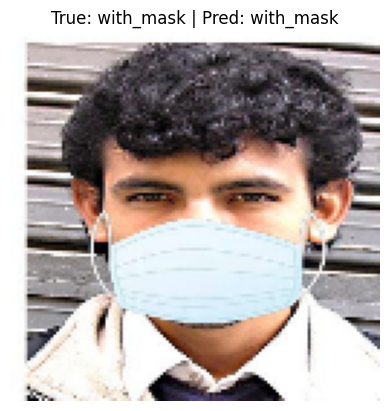

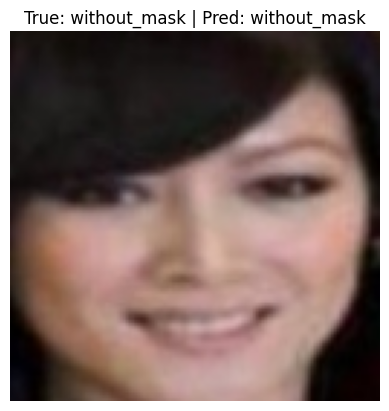

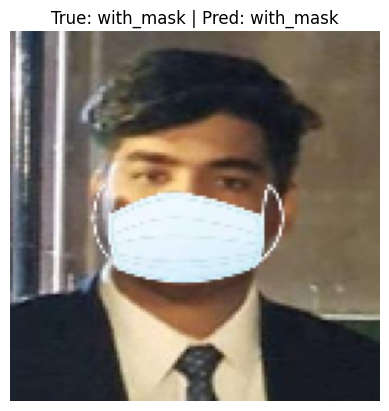

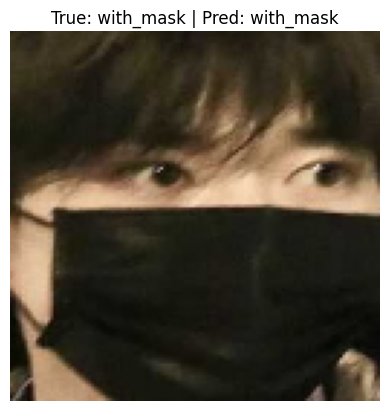

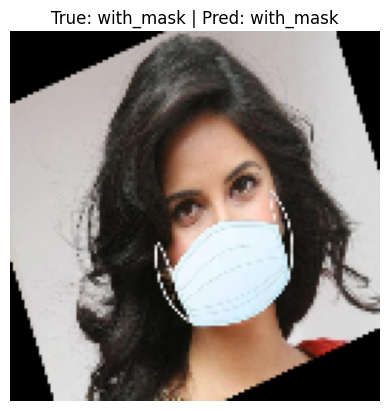

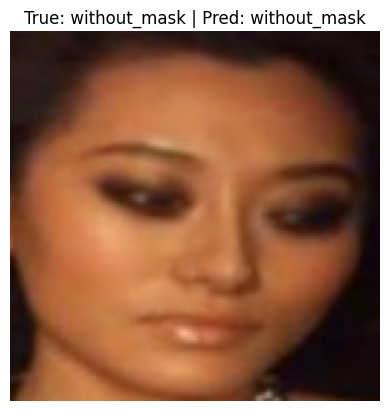

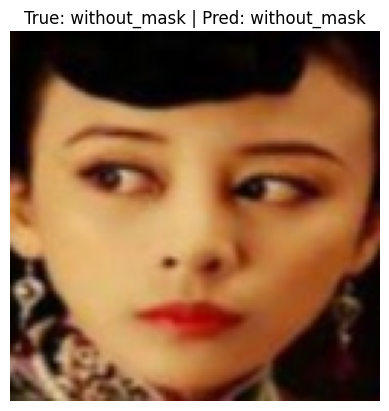

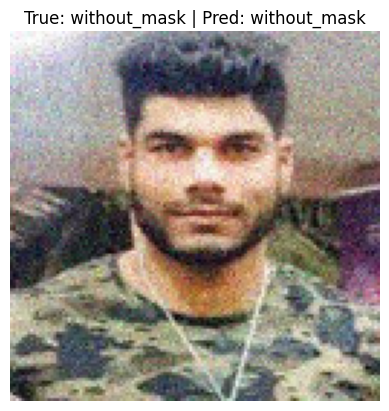

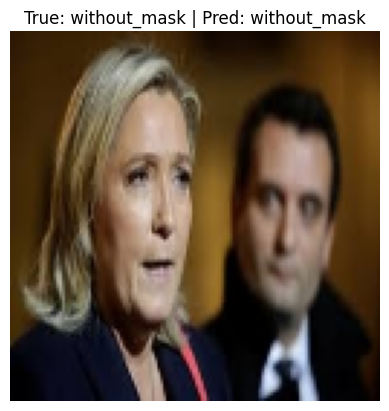

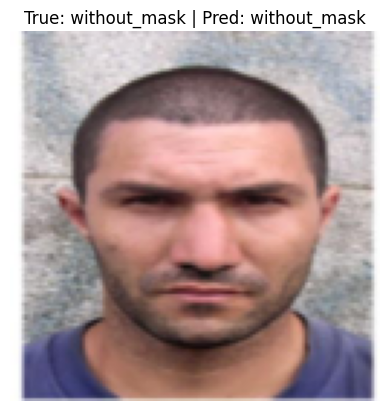

In [12]:
import random

# Pick 10 random test images
indices = random.sample(range(len(X_test)), 10)

for i in indices:
    img = X_test[i]
    true_label = categories[y_test[i]]
    pred_label = categories[y_pred[i][0]]

    plt.imshow(img)
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')
    plt.show()
